In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install gradio matplotlib seaborn scikit-learn tqdm -q

In [17]:
import os, gzip, json, re, math, time, random, pickle
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

#  Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

#  Directory Setup 
Path('results').mkdir(exist_ok=True)
Path('models').mkdir(exist_ok=True)
Path('data').mkdir(exist_ok=True)
print('Directories ready.')

Using device: cuda
Directories ready.


---
## Dataset Loading, Preprocessing & Vocabulary Construction

In [18]:

CATEGORIES = {
    'electronics': 'data/electronics.json.gz',
    'beauty':      'data/beauty.json.gz',
    'cellphones':  'data/cellphones.json.gz',
}

SAMPLES_PER_CATEGORY = 12000   
MAX_SEQ_LEN  = 128            
MAX_GEN_LEN  = 64             
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15



def load_category(path: str, category: str, max_samples: int) -> list[dict]:
    
    records = []
    with gzip.open(path, 'rt', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            text   = obj.get('reviewText', '') or obj.get('summary', '')
            rating = obj.get('overall', None)
            if not text or rating is None:
                continue
            records.append({'text': text.strip(), 'rating': float(rating), 'category': category})
            if len(records) >= max_samples:
                break
    return records


all_records = []
for cat, path in CATEGORIES.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing file: {path}  — place it in the data/ folder.')
    recs = load_category(path, cat, SAMPLES_PER_CATEGORY)
    print(f'  {cat:15s}: {len(recs):,} samples loaded')
    all_records.extend(recs)

random.shuffle(all_records)
print(f'\nTotal samples: {len(all_records):,}')

# Rating distribution
ratings = [r['rating'] for r in all_records]
for star in range(1, 6):
    print(f'  {star}★ : {ratings.count(float(star)):,}')

  electronics    : 12,000 samples loaded
  beauty         : 12,000 samples loaded
  cellphones     : 12,000 samples loaded

Total samples: 36,000
  1★ : 2,580
  2★ : 2,084
  3★ : 3,583
  4★ : 6,959
  5★ : 20,794


In [19]:

# Label Engineering
#   Sentiment (3-class):  1-2 → 0 (Negative), 3 → 1 (Neutral), 4-5 → 2 (Positive)
#   Derived feature:  Review length class — Short (≤50 words) → 0, Medium → 1, Long (>150 words) → 2


def rating_to_sentiment(rating: float) -> int:
    if rating <= 2:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

def text_to_length_class(text: str) -> int:
    n = len(text.split())
    if n <= 50:
        return 0  # Short
    elif n <= 150:
        return 1  # Medium
    else:
        return 2  # Long

SENTIMENT_NAMES    = ['Negative', 'Neutral', 'Positive']
LENGTH_CLASS_NAMES = ['Short', 'Medium', 'Long']

for rec in all_records:
    rec['sentiment']    = rating_to_sentiment(rec['rating'])
    rec['length_class'] = text_to_length_class(rec['text'])

print('Label distribution:')
for i, name in enumerate(SENTIMENT_NAMES):
    cnt = sum(1 for r in all_records if r['sentiment'] == i)
    print(f'  Sentiment {name}: {cnt:,}')
for i, name in enumerate(LENGTH_CLASS_NAMES):
    cnt = sum(1 for r in all_records if r['length_class'] == i)
    print(f'  Length {name}: {cnt:,}')

Label distribution:
  Sentiment Negative: 4,664
  Sentiment Neutral: 3,583
  Sentiment Positive: 27,753
  Length Short: 15,666
  Length Medium: 13,615
  Length Long: 6,719


In [20]:
# Text Cleaning & Simple Whitespace Tokenizer
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # remove HTML tags
    text = re.sub(r'https?://\S+', ' URL ', text)  # replace URLs
    text = re.sub(r"[^a-z0-9'\s]", ' ', text)     # keep letters, digits, apostrophes
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text: str) -> list[str]:
    """Simple whitespace tokenizer."""
    return clean_text(text).split()

# Test
sample = all_records[0]['text']
print('Original :', sample[:120])
print('Tokenized:', tokenize(sample)[:20])

Original : Sound quality is excellent for the price and it is very easy to use; I highly recommend this player.
Tokenized: ['sound', 'quality', 'is', 'excellent', 'for', 'the', 'price', 'and', 'it', 'is', 'very', 'easy', 'to', 'use', 'i', 'highly', 'recommend', 'this', 'player']


In [21]:
# Train / Val / Test Split


n = len(all_records)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

train_records = all_records[:n_train]
val_records   = all_records[n_train : n_train + n_val]
test_records  = all_records[n_train + n_val:]

print(f'Train : {len(train_records):,}')
print(f'Val   : {len(val_records):,}')
print(f'Test  : {len(test_records):,}')

Train : 25,200
Val   : 5,400
Test  : 5,400


In [22]:
# Vocabulary Construction 

MIN_FREQ = 3  
SPECIAL_TOKENS = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']

counter = Counter()
for rec in tqdm(train_records, desc='Building vocab', disable=True):
    counter.update(tokenize(rec['text']))

vocab_tokens = SPECIAL_TOKENS + [tok for tok, cnt in counter.most_common() if cnt >= MIN_FREQ]
token2idx = {tok: i for i, tok in enumerate(vocab_tokens)}
idx2token = {i: tok for tok, i in token2idx.items()}

PAD_IDX = token2idx['<PAD>']
UNK_IDX = token2idx['<UNK>']
BOS_IDX = token2idx['<BOS>']
EOS_IDX = token2idx['<EOS>']
VOCAB_SIZE = len(vocab_tokens)

print(f'Vocabulary size: {VOCAB_SIZE:,}  (min_freq={MIN_FREQ})')

def encode(text: str, max_len: int, add_special: bool = False) -> list[int]:
    """Convert text to padded index list of length max_len."""
    toks = tokenize(text)
    ids  = [token2idx.get(t, UNK_IDX) for t in toks]
    if add_special:
        ids = [BOS_IDX] + ids + [EOS_IDX]
    ids = ids[:max_len]                         # truncate
    ids = ids + [PAD_IDX] * (max_len - len(ids))  # pad
    return ids

def decode(ids: list[int]) -> str:
    return ' '.join(idx2token.get(i, '<UNK>') for i in ids if i not in {PAD_IDX, BOS_IDX, EOS_IDX})

# Save vocab for later use
with open('results/vocab.pkl', 'wb') as f:
    pickle.dump({'token2idx': token2idx, 'idx2token': idx2token}, f)
print('Vocabulary saved.')

Vocabulary size: 16,443  (min_freq=3)
Vocabulary saved.


In [23]:
# Reference Explanations for Decoder Training
SENTIMENT_LABELS = {0: 'negative', 1: 'neutral', 2: 'positive'}
LENGTH_LABELS    = {0: 'short', 1: 'medium-length', 2: 'long'}

def make_reference_explanation(rec: dict) -> str:
    sent = SENTIMENT_LABELS[rec['sentiment']]
    lc   = LENGTH_LABELS[rec['length_class']]
    cat  = rec['category']
    star = int(rec['rating'])
    templates = [
        f"this {lc} {cat} review expresses a {sent} sentiment with a {star} star rating",
        f"the reviewer gave {star} stars indicating {sent} feelings about this {cat} product",
        f"based on the {lc} review the customer has a {sent} opinion of this {cat} item",
    ]
    return random.choice(templates)

for rec in all_records:
    rec['explanation'] = make_reference_explanation(rec)

print('Sample explanation:', all_records[0]['explanation'])

Sample explanation: based on the short review the customer has a positive opinion of this electronics item


---
## Part A: Encoder-Only Transformer with Multi-Task Learning


In [24]:
class ReviewDataset(Dataset):
    def __init__(self, records: list[dict], max_len: int = MAX_SEQ_LEN):
        self.records = records
        self.max_len = max_len

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec  = self.records[idx]
        ids  = encode(rec['text'], self.max_len)
        return {
            'input_ids':    torch.tensor(ids, dtype=torch.long),
            'sentiment':    torch.tensor(rec['sentiment'],    dtype=torch.long),
            'length_class': torch.tensor(rec['length_class'], dtype=torch.long),
        }


BATCH_SIZE = 64

train_ds = ReviewDataset(train_records)
val_ds   = ReviewDataset(val_records)
test_ds  = ReviewDataset(test_records)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

Train batches: 394, Val batches: 85, Test batches: 85


In [25]:
# Positional Encoding


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)                         # (L, D)
        pos = torch.arange(0, max_len).unsqueeze(1).float()        # (L, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        pe = pe.unsqueeze(0)                                        # (1, L, D)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, D)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)



# Scaled Dot-Product Attention (manual, no nn.MultiheadAttention)
def scaled_dot_product_attention(
    Q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    d_k    = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # (B,H,Lq,Lk)
    if mask is not None:
        scores = scores + mask
    weights = F.softmax(scores, dim=-1)
    context = torch.matmul(weights, V)                               # (B,H,Lq,d_k)
    return context, weights



# Multi-Head Attention (manual implementation)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_k      = d_model // n_heads

        # Projection matrices for Q, K, V and output
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
     
        B, L, _ = x.size()
        x = x.view(B, L, self.n_heads, self.d_k)
        return x.transpose(1, 2)  # (B, H, L, d_k)

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
     
        B, H, L, d_k = x.size()
        x = x.transpose(1, 2).contiguous()
        return x.view(B, L, H * d_k)

    def forward(
        self,
        query: torch.Tensor,
        key:   torch.Tensor,
        value: torch.Tensor,
        mask:  torch.Tensor | None = None,
    ) -> torch.Tensor:
        Q = self._split_heads(self.W_Q(query)) 
        K = self._split_heads(self.W_K(key))
        V = self._split_heads(self.W_V(value))

        context, _ = scaled_dot_product_attention(Q, K, V, mask)
        context    = self._merge_heads(context)  # (B,L,D)
        return self.dropout(self.W_O(context))



# Position-wise Feed-Forward Network
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# Encoder Block
class EncoderBlock(nn.Module):

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff    = FeedForward(d_model, d_ff, dropout)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor | None = None) -> torch.Tensor:
        # Self-attention with residual
        normed = self.norm1(x)
        x = x + self.attn(normed, normed, normed, pad_mask)
        # Feed-forward with residual
        x = x + self.ff(self.norm2(x))
        return x


print('Transformer building blocks defined.')

Transformer building blocks defined.


In [26]:

# Encoder-Only Transformer for Multi-Task Classification
class EncoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model:    int = 256,
        n_heads:    int = 8,
        n_layers:   int = 4,
        d_ff:       int = 512,
        max_len:    int = MAX_SEQ_LEN,
        n_sent:     int = 3,
        n_len:      int = 3,
        dropout:    float = 0.1,
        pad_idx:    int = 0,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model

        # Token embedding + [CLS] token
        self.embedding = nn.Embedding(vocab_size + 1, d_model, padding_idx=pad_idx)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        self.pos_enc = PositionalEncoding(d_model, max_len + 1, dropout)

        self.layers = nn.ModuleList([
            EncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

        # Classification heads
        self.sentiment_head    = nn.Linear(d_model, n_sent)
        self.length_class_head = nn.Linear(d_model, n_len)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_pad_mask(self, input_ids: torch.Tensor) -> torch.Tensor:
        is_pad  = input_ids.eq(self.pad_idx)                 # (B, L)
        cls_col = torch.zeros(input_ids.size(0), 1, dtype=torch.bool, device=input_ids.device)
        is_pad  = torch.cat([cls_col, is_pad], dim=1)        # (B, L+1)
        mask    = is_pad.unsqueeze(1).unsqueeze(2).float()   # (B,1,1,L+1)
        mask    = mask.masked_fill(mask.bool(), float('-inf'))
        return mask

    def forward(self, input_ids: torch.Tensor):
        B = input_ids.size(0)

        # Token embeddings
        tok_emb = self.embedding(input_ids)        

        # Prepend [CLS]
        cls     = self.cls_token.expand(B, -1, -1)    
        x       = torch.cat([cls, tok_emb], dim=1)   
        x       = self.pos_enc(x)
        mask    = self.make_pad_mask(input_ids)

        for layer in self.layers:
            x = layer(x, mask)

        x = self.norm(x)

        cls_out = x[:, 0, :]                                   
        sent_logits = self.sentiment_head(cls_out)            
        lc_logits   = self.length_class_head(cls_out)         

        return sent_logits, lc_logits, cls_out


# ── Hyperparameters 
ENC_N_HEADS  = 8
ENC_N_LAYERS = 4
ENC_D_FF     = 512
ENC_DROPOUT  = 0.1
ENC_LR       = 2e-4   # slightly lower for more stable convergence
ENC_EPOCHS   = 15     # more epochs to let minority classes learn
SENT_LOSS_W  = 0.7    # increased — sentiment is harder
LC_LOSS_W    = 0.3    # reduced — length-class is already 94%

encoder_model = EncoderOnlyTransformer(
    vocab_size = VOCAB_SIZE,
    d_model    = ENC_D_MODEL,
    n_heads    = ENC_N_HEADS,
    n_layers   = ENC_N_LAYERS,
    d_ff       = ENC_D_FF,
    dropout    = ENC_DROPOUT,
    pad_idx    = PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in encoder_model.parameters() if p.requires_grad)
print(f'Encoder parameters: {total_params:,}')

Encoder parameters: 6,316,294


In [27]:
# Training Loop
sent_class_weights = torch.tensor([2.5, 4.0, 1.0]).to(DEVICE)  
sent_criterion = nn.CrossEntropyLoss(weight=sent_class_weights)
lc_criterion   = nn.CrossEntropyLoss()  

optimizer  = AdamW(encoder_model.parameters(), lr=ENC_LR, weight_decay=1e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=ENC_EPOCHS)


history = {
    'train_loss': [], 'val_loss': [],
    'train_sent_acc': [], 'val_sent_acc': [],
    'train_lc_acc':   [], 'val_lc_acc':   [],
}


def run_encoder_epoch(loader, train=True):
    encoder_model.train(train)
    total_loss = 0.0
    sent_correct = lc_correct = total = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, leave=False, desc='train' if train else 'eval '):
            ids  = batch['input_ids'].to(DEVICE)
            sent = batch['sentiment'].to(DEVICE)
            lc   = batch['length_class'].to(DEVICE)

            sent_logits, lc_logits, _ = encoder_model(ids)

            loss_sent = sent_criterion(sent_logits, sent)
            loss_lc   = lc_criterion(lc_logits, lc)
            loss      = SENT_LOSS_W * loss_sent + LC_LOSS_W * loss_lc

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(encoder_model.parameters(), 1.0)
                optimizer.step()

            total_loss   += loss.item() * ids.size(0)
            sent_correct += (sent_logits.argmax(1) == sent).sum().item()
            lc_correct   += (lc_logits.argmax(1) == lc).sum().item()
            total        += ids.size(0)

    return total_loss / total, sent_correct / total, lc_correct / total


print('Starting encoder training…')
best_val_loss = float('inf')

for epoch in range(1, ENC_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_sa, tr_la = run_encoder_epoch(train_loader, train=True)
    vl_loss, vl_sa, vl_la = run_encoder_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_sent_acc'].append(tr_sa)
    history['val_sent_acc'].append(vl_sa)
    history['train_lc_acc'].append(tr_la)
    history['val_lc_acc'].append(vl_la)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(encoder_model.state_dict(), 'models/encoder_best.pt')

    dt = time.time() - t0
    print(
        f'Epoch {epoch:02d}/{ENC_EPOCHS} | '
        f'Loss: {tr_loss:.4f}/{vl_loss:.4f} | '
        f'Sent: {tr_sa:.3f}/{vl_sa:.3f} | '
        f'Len: {tr_la:.3f}/{vl_la:.3f} | '
        f'{dt:.1f}s'
    )

print('\nTraining complete. Loading best checkpoint…')
encoder_model.load_state_dict(torch.load('models/encoder_best.pt', map_location=DEVICE))

Starting encoder training…


Epoch 01/15 | Loss: 0.8170/0.7677 | Sent: 0.667/0.779 | Len: 0.912/0.941 | 28.5s


Epoch 02/15 | Loss: 0.7749/0.7594 | Sent: 0.731/0.779 | Len: 0.940/0.942 | 28.1s


Epoch 03/15 | Loss: 0.7658/0.7217 | Sent: 0.736/0.779 | Len: 0.943/0.944 | 28.1s


Epoch 04/15 | Loss: 0.7063/0.6378 | Sent: 0.704/0.780 | Len: 0.944/0.944 | 28.1s


...

Epoch 12/15 | Loss: 0.4588/0.6235 | Sent: 0.806/0.784 | Len: 0.946/0.942 | 28.3s


Epoch 13/15 | Loss: 0.4504/0.6386 | Sent: 0.805/0.787 | Len: 0.947/0.942 | 28.6s


Epoch 14/15 | Loss: 0.4454/0.6406 | Sent: 0.810/0.784 | Len: 0.946/0.942 | 28.5s


Epoch 15/15 | Loss: 0.4436/0.6259 | Sent: 0.812/0.778 | Len: 0.947/0.942 | 28.3s

Training complete. Loading best checkpoint…


<All keys matched successfully>

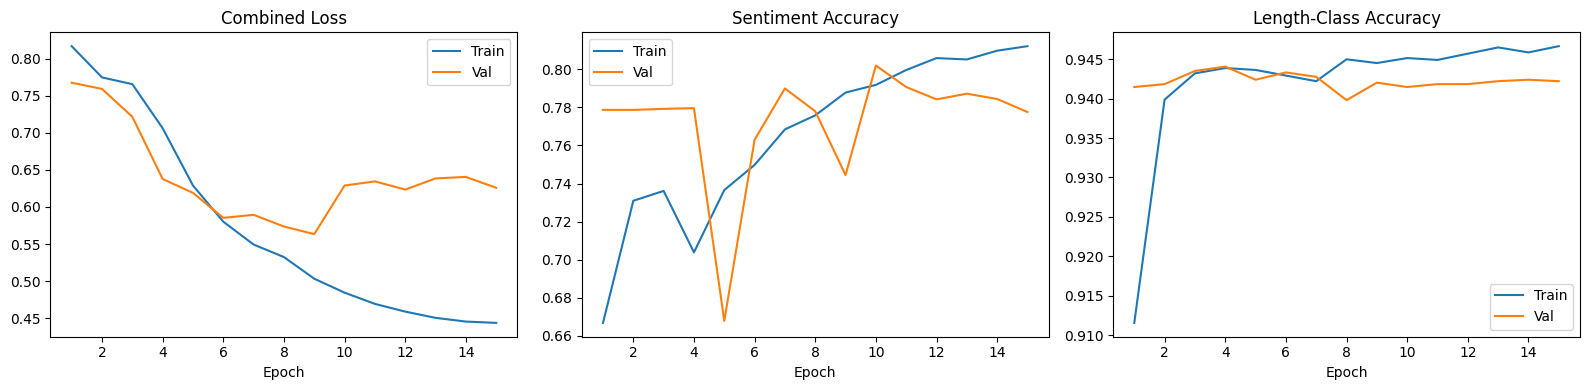

Curves saved.


In [28]:
# Learning Curves 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs = range(1, ENC_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Combined Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs, history['train_sent_acc'], label='Train')
axes[1].plot(epochs, history['val_sent_acc'],   label='Val')
axes[1].set_title('Sentiment Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs, history['train_lc_acc'], label='Train')
axes[2].plot(epochs, history['val_lc_acc'],   label='Val')
axes[2].set_title('Length-Class Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('results/encoder_learning_curves.png', dpi=150)
plt.show()
print('Curves saved.')

Testing: 100%|██████████| 85/85 [00:02<00:00, 35.19it/s]


 Sentiment Classification (Test) 
              precision    recall  f1-score   support

    Negative       0.70      0.45      0.55       724
     Neutral       0.20      0.50      0.29       538
    Positive       0.92      0.81      0.86      4138

    accuracy                           0.73      5400
   macro avg       0.61      0.58      0.57      5400
weighted avg       0.82      0.73      0.76      5400

 Length-Class Classification (Test) 
              precision    recall  f1-score   support

       Short       0.99      0.99      0.99      2323
      Medium       0.99      0.85      0.92      2053
        Long       0.78      1.00      0.88      1024

    accuracy                           0.94      5400
   macro avg       0.92      0.95      0.93      5400
weighted avg       0.95      0.94      0.94      5400



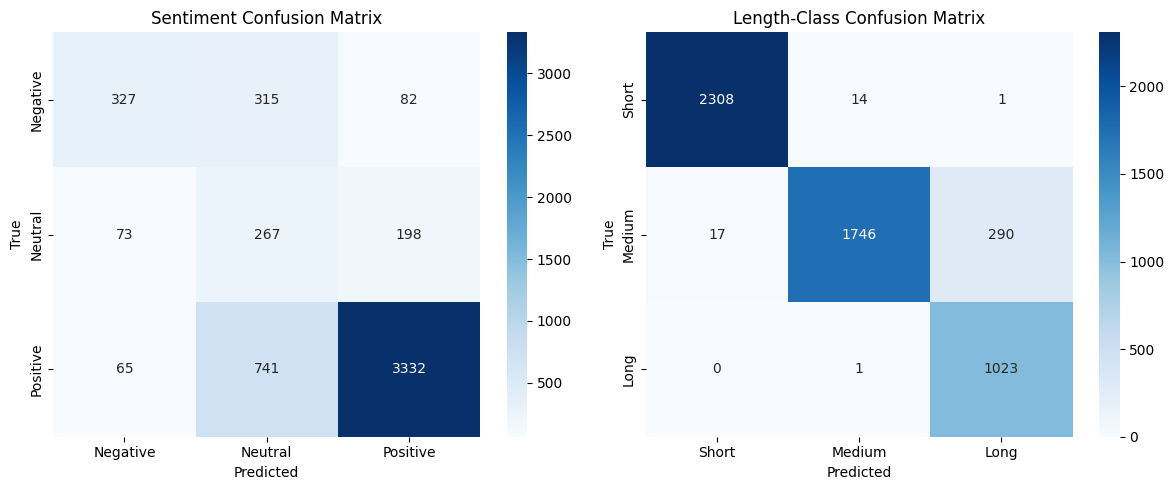

In [29]:
#  Test-Set Evaluation 
encoder_model.eval()

all_sent_preds, all_sent_true = [], []
all_lc_preds,   all_lc_true  = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        ids  = batch['input_ids'].to(DEVICE)
        sent = batch['sentiment']
        lc   = batch['length_class']

        sl, ll, _ = encoder_model(ids)
        all_sent_preds.extend(sl.argmax(1).cpu().numpy())
        all_sent_true.extend(sent.numpy())
        all_lc_preds.extend(ll.argmax(1).cpu().numpy())
        all_lc_true.extend(lc.numpy())

print(' Sentiment Classification (Test) ')
print(classification_report(all_sent_true, all_sent_preds, target_names=SENTIMENT_NAMES))

print(' Length-Class Classification (Test) ')
print(classification_report(all_lc_true, all_lc_preds, target_names=LENGTH_CLASS_NAMES))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, names, title in [
    (axes[0], all_sent_true, all_sent_preds, SENTIMENT_NAMES,    'Sentiment Confusion Matrix'),
    (axes[1], all_lc_true,   all_lc_preds,  LENGTH_CLASS_NAMES, 'Length-Class Confusion Matrix'),
]:
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names,
                cmap='Blues', ax=ax)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('results/encoder_confusion_matrices.png', dpi=150)
plt.show()